# New York median income

**Source of truth:** ACS 1-year median household income (table B19013), ingested by the
`census-acs-profile` dataset into the `demographics` table (columns `median_household_income`,
`mean_household_income`, `per_capita_income`).

That dataset is currently **BLOCKED**: the Census API requires `CENSUS_API_KEY`, which is not
configured. Until it is, this notebook cannot show a median — it falls back to the closest official
series that *is* ingested (BLS QCEW **average** annual pay per covered job, which is a mean of wages,
not a household median) and says so.

To unlock the real series:

```
# 1. request a free key: https://api.census.gov/data/key_signup.html
# 2. put CENSUS_API_KEY=... in .env
# 3. uv run electiondata ingest census-acs-profile -o years=2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2021,2022,2023
```

then re-run this notebook; the first section will populate automatically.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import electiondata as ed
from electiondata.exceptions import DatasetUnavailableError

try:
    acs = ed.demographics.state(state="NY")
except DatasetUnavailableError as exc:
    acs = pd.DataFrame()
    print("ACS not available:", exc)

acs_available = not acs.empty and acs["median_household_income"].notna().any()
print("ACS median household income for New York available:", acs_available)

ACS not available: table 'demographics' has no processed data yet; run `electiondata ingest ...` first
ACS median household income for New York available: False


## 1. ACS median household income (populates once `census-acs-profile` is ingested)

In [2]:
if acs_available:
    inc = acs.sort_values("year")[["year", "survey", "median_household_income", "mean_household_income",
                                   "per_capita_income", "publication_date"]].reset_index(drop=True)
    display(inc)
    ax = inc.set_index("year")[["median_household_income", "mean_household_income", "per_capita_income"]].plot(
        marker="o", figsize=(9, 4.5))
    ax.set_title("New York household income (ACS 1-year, current dollars)")
    ax.set_ylabel("USD")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No ACS rows: median household income cannot be shown. Set CENSUS_API_KEY and ingest census-acs-profile.")

No ACS rows: median household income cannot be shown. Set CENSUS_API_KEY and ingest census-acs-profile.


## 2. Fallback: average annual pay per covered job (BLS QCEW)

This is the **average** wage per job across all covered employment in New York (QCEW `avg_annual_pay`,
industry code 10, all ownerships). It is *not* a median and *not* household income — it is shown only
because it is the income-like series currently in the store. Only the years ingested so far appear
(`electiondata ingest bls-qcew -o years=...` adds more).

,year,avg_annual_pay,annual_avg_weekly_wage,annual_avg_employment,publication_date
0,2023,91428.0,1758.0,9471806.0,2024-06-30
1,2024,95082.0,1829.0,9705821.0,2025-06-30


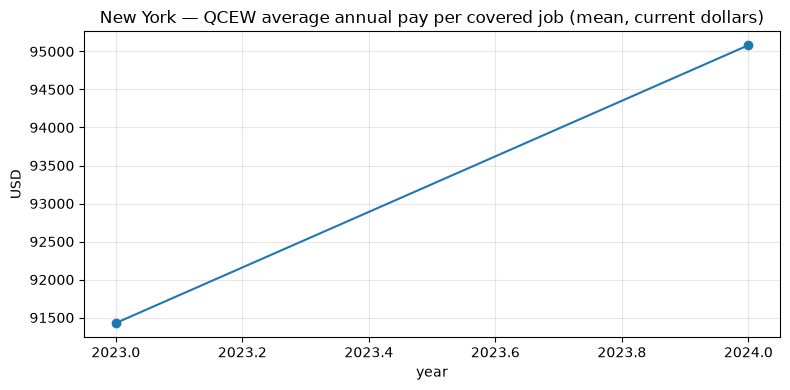

In [3]:
ind = ed.economics.industry(state="NY")
tot = (ind[(ind["industry_code"] == "10") & (ind["own_code"] == "0")]
       .sort_values("year")[["year", "avg_annual_pay", "annual_avg_weekly_wage", "annual_avg_employment", "publication_date"]]
       .reset_index(drop=True))
display(tot)
ax = tot.set_index("year")["avg_annual_pay"].plot(marker="o", figsize=(8, 4))
ax.set_title("New York — QCEW average annual pay per covered job (mean, current dollars)")
ax.set_ylabel("USD")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Point-in-time view

For modelling, use `as_of` so only values published by the forecast date are used, e.g. the ACS
figure available on 15 Oct 2024 is the 2023 estimate (released September 2024):

In [4]:
snap = ed.demographics.snapshot("2024-10-15", state="NY")
cols = [c for c in ("acs_year", "median_household_income", "per_capita_income", "population_year", "population") if c in snap.columns]
snap[["state", *cols]]

,state,population_year,population
0,NY,2023,19571216.0
